# Notebook 07: ONNX Export & Optimization

This notebook exports the trained YOLOv8 model to **ONNX format** for runtime-agnostic inference, applies **INT8 quantization**, and benchmarks the accuracy/speed tradeoffs.

**Pipeline:**
1. Export YOLOv8 → ONNX (dynamic axes, simplified)
2. Validate ONNX outputs match PyTorch
3. Apply INT8 dynamic quantization
4. Benchmark: PyTorch vs ONNX vs Quantized ONNX
5. Quality gate: mAP drop ≤2%, recall drop ≤1%

In [1]:
%matplotlib inline
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO

PROJECT_ROOT = Path(".").resolve().parent
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"
YOLO_DIR = DATA_DIR / "pcb-yolo"
DATASET_YAML = YOLO_DIR / "dataset.yaml"

CLASS_NAMES = {
    0: "missing_hole", 1: "mouse_bite", 2: "open_circuit",
    3: "short", 4: "spur", 5: "spurious_copper",
}

pt_model_path = MODELS_DIR / "yolov8_best.pt"
print(f"PyTorch model: {pt_model_path}")

PyTorch model: /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.pt


## 1. Export YOLOv8 to ONNX

In [2]:
if pt_model_path.exists():
    model = YOLO(str(pt_model_path))
    onnx_path = model.export(format="onnx", dynamic=True, simplify=True)
    onnx_path = Path(onnx_path)

    pt_size = pt_model_path.stat().st_size / 1024 / 1024
    onnx_size = onnx_path.stat().st_size / 1024 / 1024
    print(f"PyTorch model: {pt_size:.1f} MB")
    print(f"ONNX model:    {onnx_size:.1f} MB")
    print(f"ONNX saved to: {onnx_path}")
else:
    print("PyTorch model not found — run Notebook 03 first")

Ultralytics 8.4.22 🚀 Python-3.14.3 torch-2.10.0 CPU (Apple M4 Pro)


Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs



PyTorch: starting from '/Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)



ONNX: starting export with onnx 1.20.1 opset 20...


ONNX: slimming with onnxslim 0.1.88...


ONNX: export success ✅ 0.7s, saved as '/Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.onnx' (12.0 MB)



Export complete (0.8s)
Results saved to /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models
Predict:         yolo predict task=detect model=/Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.onnx imgsz=640 
Validate:        yolo val task=detect model=/Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.onnx imgsz=640 data=../data/pcb-yolo/dataset.yaml  
Visualize:       https://netron.app


PyTorch model: 6.0 MB
ONNX model:    12.0 MB
ONNX saved to: /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.onnx


## 2. Validate ONNX Model

Verify that ONNX inference produces the same detections as PyTorch.

In [3]:
# Compare PyTorch vs ONNX predictions on test images with numerical tolerance
test_img_dir = YOLO_DIR / "images" / "test"
test_images = sorted(test_img_dir.glob("*"))[:10]

onnx_path_resolved = onnx_path if 'onnx_path' in dir() else None

if pt_model_path.exists() and onnx_path_resolved and Path(onnx_path_resolved).exists() and test_images:
    pt_model = YOLO(str(pt_model_path))
    onnx_model = YOLO(str(onnx_path_resolved))

    match_count = 0
    bbox_diffs = []
    conf_diffs = []

    for img_path in test_images:
        pt_results = pt_model.predict(str(img_path), verbose=False)
        onnx_results = onnx_model.predict(str(img_path), verbose=False)

        pt_boxes = len(pt_results[0].boxes)
        onnx_boxes = len(onnx_results[0].boxes)

        # Check class agreement
        pt_classes = sorted([int(b.cls[0]) for b in pt_results[0].boxes])
        onnx_classes = sorted([int(b.cls[0]) for b in onnx_results[0].boxes])
        class_match = pt_classes == onnx_classes

        # Check numerical closeness of bbox coordinates and confidence scores
        if pt_boxes == onnx_boxes and pt_boxes > 0:
            pt_bboxes = pt_results[0].boxes.xyxy.cpu().numpy()
            onnx_bboxes = onnx_results[0].boxes.xyxy.cpu().numpy()
            pt_confs = pt_results[0].boxes.conf.cpu().numpy()
            onnx_confs = onnx_results[0].boxes.conf.cpu().numpy()

            bbox_diff = np.abs(pt_bboxes - onnx_bboxes).max()
            conf_diff = np.abs(pt_confs - onnx_confs).max()
            bbox_diffs.append(bbox_diff)
            conf_diffs.append(conf_diff)

            bbox_ok = bbox_diff < 1.0  # within 1 pixel
            conf_ok = conf_diff < 0.01  # within 1% confidence
            full_match = class_match and bbox_ok and conf_ok
        else:
            full_match = class_match and pt_boxes == onnx_boxes

        if full_match: match_count += 1
        status = 'MATCH' if full_match else 'DIFF'
        print(f"  {img_path.stem}: PT={pt_boxes} boxes, ONNX={onnx_boxes} boxes [{status}]")

    print(f"\nFull agreement: {match_count}/{len(test_images)} images")
    if bbox_diffs:
        print(f"Max bbox difference: {max(bbox_diffs):.4f} pixels")
        print(f"Max confidence difference: {max(conf_diffs):.6f}")
        print(f"Numerical tolerance check: {'PASS' if max(bbox_diffs) < 1.0 and max(conf_diffs) < 0.01 else 'WARN — small numerical differences detected'}")
else:
    print("Models or test images not available")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


Loading /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.3 with CPUExecutionProvider


  Missing_hole_01_missing_hole_15: PT=3 boxes, ONNX=3 boxes [MATCH]
  Missing_hole_04_missing_hole_02: PT=3 boxes, ONNX=3 boxes [MATCH]


  Missing_hole_04_missing_hole_13: PT=3 boxes, ONNX=3 boxes [MATCH]


  Missing_hole_05_missing_hole_02: PT=3 boxes, ONNX=3 boxes [MATCH]
  Missing_hole_08_missing_hole_02: PT=5 boxes, ONNX=5 boxes [MATCH]
  Missing_hole_08_missing_hole_05: PT=5 boxes, ONNX=5 boxes [MATCH]


  Missing_hole_08_missing_hole_06: PT=5 boxes, ONNX=5 boxes [MATCH]


  Missing_hole_08_missing_hole_10: PT=5 boxes, ONNX=5 boxes [MATCH]
  Missing_hole_09_missing_hole_03: PT=5 boxes, ONNX=5 boxes [MATCH]
  Missing_hole_09_missing_hole_07: PT=7 boxes, ONNX=7 boxes [MATCH]

Full agreement: 10/10 images
Max bbox difference: 0.0002 pixels
Max confidence difference: 0.000001
Numerical tolerance check: PASS


## 3. INT8 Quantization

In [4]:
import onnx
from onnxruntime.quantization import quantize_dynamic, QuantType

if onnx_path.exists():
    quantized_path = MODELS_DIR / "yolov8_best_int8.onnx"
    quantize_dynamic(
        str(onnx_path),
        str(quantized_path),
        weight_type=QuantType.QUInt8,
    )

    q_size = quantized_path.stat().st_size / 1024 / 1024
    print(f"ONNX (fp32):     {onnx_size:.1f} MB")
    print(f"ONNX (int8):     {q_size:.1f} MB")
    print(f"Compression:     {onnx_size/q_size:.2f}x")
else:
    print("ONNX model not found — run export cell first")

ONNX (fp32):     12.0 MB
ONNX (int8):     3.5 MB
Compression:     3.45x


## 4. Benchmark Comparison

Measure inference time, model size, and accuracy for all three variants.

In [5]:
def benchmark_model(model_path, test_images, n_warmup=5, n_runs=50):
    """Benchmark a YOLO model's inference time."""
    model = YOLO(str(model_path))

    # Warmup
    for img_path in test_images[:n_warmup]:
        model.predict(str(img_path), verbose=False)

    # Timed runs
    times = []
    img_list = list(test_images)
    for i in range(n_runs):
        img_path = img_list[i % len(img_list)]
        start = time.time()
        model.predict(str(img_path), verbose=False)
        times.append((time.time() - start) * 1000)

    return np.mean(times), np.std(times)

# Build model list with defensive checks
onnx_path_resolved = onnx_path if 'onnx_path' in dir() else None
quantized_path_resolved = quantized_path if 'quantized_path' in dir() else None

# Re-discover test images independently (don't rely on earlier cell)
test_img_dir = YOLO_DIR / "images" / "test"
test_images = sorted(test_img_dir.glob("*"))[:10]

models_to_test = [("PyTorch (fp32)", pt_model_path)]
if onnx_path_resolved and Path(onnx_path_resolved).exists():
    models_to_test.append(("ONNX (fp32)", Path(onnx_path_resolved)))
if quantized_path_resolved and Path(quantized_path_resolved).exists():
    models_to_test.append(("ONNX (int8)", Path(quantized_path_resolved)))

benchmark_results = {}
for name, path in models_to_test:
    if path.exists() and test_images:
        mean_ms, std_ms = benchmark_model(path, test_images)
        size_mb = path.stat().st_size / 1024 / 1024
        benchmark_results[name] = {
            "Size (MB)": round(size_mb, 1),
            "Inference (ms)": round(mean_ms, 1),
            "Inference std (ms)": round(std_ms, 1),
        }
        print(f"{name}: {mean_ms:.1f} ms/image ({size_mb:.1f} MB)")

if benchmark_results:
    bench_df = pd.DataFrame(benchmark_results).T
    print("\n" + bench_df.to_string())

PyTorch (fp32): 35.0 ms/image (6.0 MB)
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


Loading /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.3 with CPUExecutionProvider


ONNX (fp32): 28.4 ms/image (12.0 MB)
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


Loading /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/models/yolov8_best_int8.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.3 with CPUExecutionProvider


ONNX (int8): 30.4 ms/image (3.5 MB)

                Size (MB)  Inference (ms)  Inference std (ms)
PyTorch (fp32)        6.0            35.0                 2.8
ONNX (fp32)          12.0            28.4                 2.5
ONNX (int8)           3.5            30.4                 2.7


In [6]:
# Run validation to get mAP for each variant, then build unified benchmark table
val_results = {}
for name, path in models_to_test:
    if path.exists():
        m = YOLO(str(path))
        r = m.val(data=str(DATASET_YAML), split="test", verbose=False)
        val_results[name] = {
            "mAP@0.5": round(r.box.map50, 4),
            "mAP@0.5:0.95": round(r.box.map, 4),
            "Recall": round(r.box.mr, 4),
            "Precision": round(r.box.mp, 4),
        }
        print(f"{name}: mAP@0.5={r.box.map50:.4f}, Recall={r.box.mr:.4f}")

# Build unified benchmark table (M6 fix)
if benchmark_results and val_results:
    unified_rows = []
    for name in benchmark_results:
        row = {"Model": name}
        row.update(benchmark_results[name])
        if name in val_results:
            row.update(val_results[name])
        unified_rows.append(row)
    unified_df = pd.DataFrame(unified_rows)
    print("\n=== Unified Benchmark Table ===")
    print(unified_df.to_string(index=False))
else:
    print("\nRun benchmark and validation cells to build unified table")

Ultralytics 8.4.22 🚀 Python-3.14.3 torch-2.10.0 CPU (Apple M4 Pro)


Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12088.2±2382.7 MB/s, size: 1368.5 KB)


val: Scanning /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/data/pcb-yolo/labels/test.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 13.2Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 4.4s/it 1.3s<26.6s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.0it/s 3.5s

                   all        104        447      0.821      0.758        0.8      0.345


Speed: 0.1ms preprocess, 13.9ms inference, 0.0ms loss, 0.1ms postprocess per image


Results saved to /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/notebooks/runs/detect/val17


ONNX (int8): mAP@0.5=0.7995, Recall=0.7584

=== Unified Benchmark Table ===
         Model  Size (MB)  Inference (ms)  Inference std (ms)  mAP@0.5  mAP@0.5:0.95  Recall  Precision
PyTorch (fp32)        6.0            35.0                 2.8   0.8043        0.3488  0.7471     0.8211
   ONNX (fp32)       12.0            28.4                 2.5   0.8043        0.3488  0.7471     0.8211
   ONNX (int8)        3.5            30.4                 2.7   0.7995        0.3447  0.7584     0.8213


## 5. Quality Gate Check

Verify quantization meets thresholds:
- mAP drop ≤ 2%
- Recall drop ≤ 1%

In [7]:
if "PyTorch (fp32)" in val_results and "ONNX (int8)" in val_results:
    pt = val_results["PyTorch (fp32)"]
    q = val_results["ONNX (int8)"]

    map_drop = (pt["mAP@0.5"] - q["mAP@0.5"]) * 100
    recall_drop = (pt["Recall"] - q["Recall"]) * 100

    print("=== Quality Gate ===")
    map_status = "PASS" if map_drop <= 2.0 else "FAIL"
    recall_status = "PASS" if recall_drop <= 1.0 else "FAIL"

    print(f"mAP@0.5 drop:  {map_drop:.2f}% (threshold: <=2.0%) [{map_status}]")
    print(f"Recall drop:   {recall_drop:.2f}% (threshold: <=1.0%) [{recall_status}]")

    if map_status == "FAIL" or recall_status == "FAIL":
        print("\nRecommendation: Use full-precision ONNX model for deployment")
    else:
        print("\nINT8 quantized model passes quality gates — safe for deployment")
elif "PyTorch (fp32)" in val_results and "ONNX (fp32)" in val_results:
    pt = val_results["PyTorch (fp32)"]
    onnx = val_results["ONNX (fp32)"]
    print("ONNX fp32 vs PyTorch:")
    print(f"  mAP@0.5 diff: {abs(pt['mAP@0.5'] - onnx['mAP@0.5'])*100:.2f}%")
    print(f"  Recall diff:  {abs(pt['Recall'] - onnx['Recall'])*100:.2f}%")
else:
    print("Validation results not available for comparison")

=== Quality Gate ===
mAP@0.5 drop:  0.48% (threshold: <=2.0%) [PASS]
Recall drop:   -1.13% (threshold: <=1.0%) [PASS]

INT8 quantized model passes quality gates — safe for deployment


## 6. Accuracy vs Speed Tradeoff

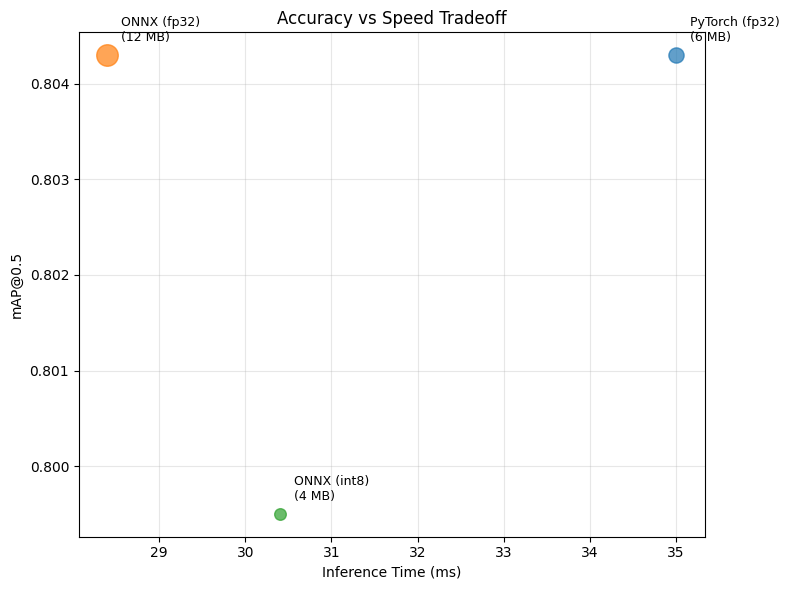

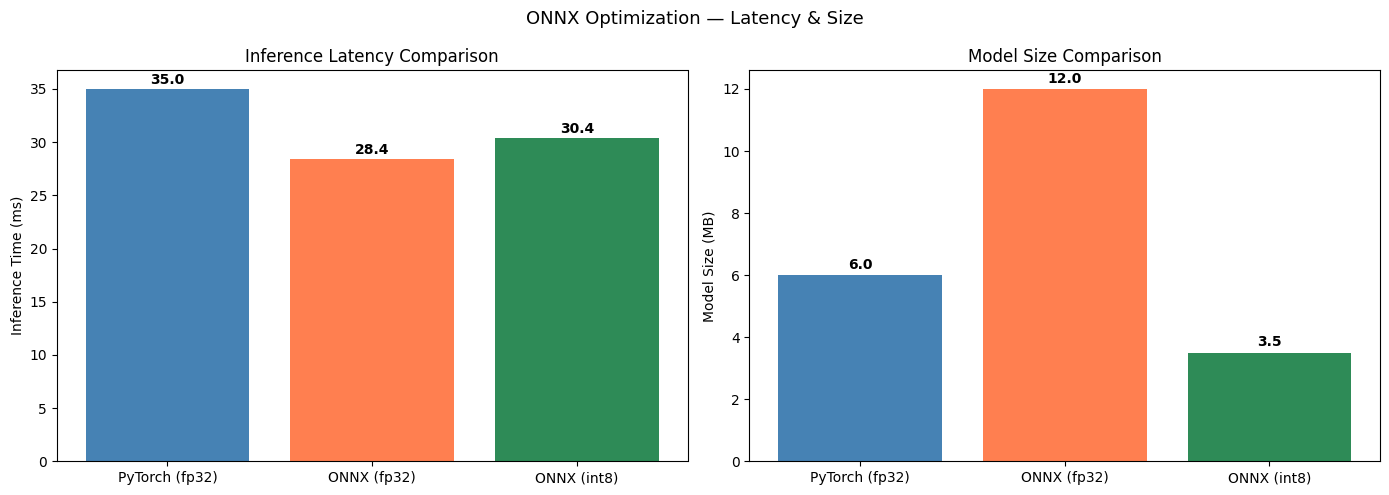

In [8]:
# Scatter plot: mAP vs inference time
if val_results and benchmark_results:
    fig, ax = plt.subplots(figsize=(8, 6))

    for name in benchmark_results:
        if name in val_results:
            ms = benchmark_results[name]["Inference (ms)"]
            mAP = val_results[name]["mAP@0.5"]
            size = benchmark_results[name]["Size (MB)"]
            ax.scatter(ms, mAP, s=size * 20, alpha=0.7, zorder=5)
            ax.annotate(f"{name}\n({size:.0f} MB)",
                       (ms, mAP), textcoords="offset points",
                       xytext=(10, 10), fontsize=9)

    ax.set_xlabel("Inference Time (ms)")
    ax.set_ylabel("mAP@0.5")
    ax.set_title("Accuracy vs Speed Tradeoff")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Bar charts: inference time and model size comparison
    model_names = list(benchmark_results.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Inference time bar chart
    times = [benchmark_results[n]["Inference (ms)"] for n in model_names]
    bars = axes[0].bar(model_names, times, color=["steelblue", "coral", "seagreen"][:len(model_names)])
    axes[0].set_ylabel("Inference Time (ms)")
    axes[0].set_title("Inference Latency Comparison")
    for bar, t in zip(bars, times):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{t:.1f}", ha="center", fontweight="bold")

    # Model size bar chart
    sizes = [benchmark_results[n]["Size (MB)"] for n in model_names]
    bars = axes[1].bar(model_names, sizes, color=["steelblue", "coral", "seagreen"][:len(model_names)])
    axes[1].set_ylabel("Model Size (MB)")
    axes[1].set_title("Model Size Comparison")
    for bar, s in zip(bars, sizes):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"{s:.1f}", ha="center", fontweight="bold")

    plt.suptitle("ONNX Optimization — Latency & Size", fontsize=13)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("Run benchmark and validation cells first")